In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
df.sample(2)

,Survived,Age,Fare
634,0,9.0,27.900
13,0,39.0,31.275


In [3]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [4]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [5]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [6]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

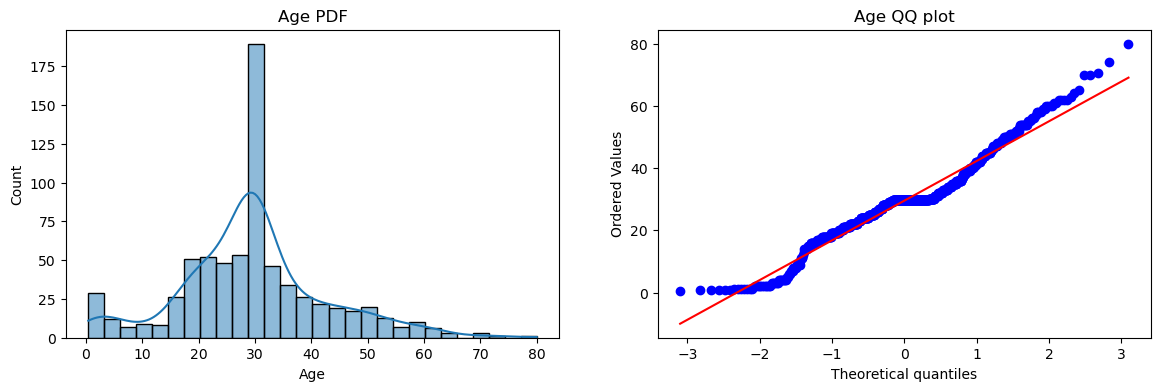

In [8]:
# after completing the work at tts lets have a quick check on distribution of data

plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ plot')

plt.show()

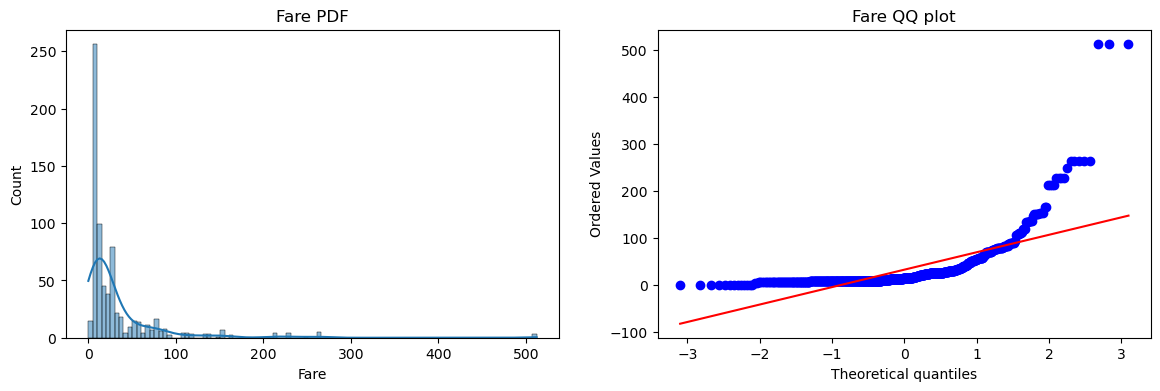

In [9]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ plot')

plt.show()

In [10]:
lr = LogisticRegression()
clf = DecisionTreeClassifier()

In [11]:
lr.fit(X_train, y_train)
clf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_clf = clf.predict(X_test)

print(f"LR Accuracy : {accuracy_score(y_pred_lr, y_test)}")
print(f"DT Accuracy : {accuracy_score(y_pred_clf, y_test)}")


LR Accuracy : 0.6480446927374302
DT Accuracy : 0.6703910614525139


In [12]:
# define Transformer

trf = FunctionTransformer(func=np.log1p)

In [13]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [14]:
lr = LogisticRegression()
clf = DecisionTreeClassifier()

In [15]:
lr.fit(X_train_transformed, y_train)
clf.fit(X_train_transformed, y_train)

y_pred_lr = lr.predict(X_test_transformed)
y_pred_clf = clf.predict(X_test_transformed)

print(f"LR Accuracy : {accuracy_score(y_pred_lr, y_test)}")
print(f"DT Accuracy : {accuracy_score(y_pred_clf, y_test)}")

LR Accuracy : 0.6815642458100558
DT Accuracy : 0.6871508379888268


In [16]:
# lets transform full X

X_transformed = trf.fit_transform(X)

lr = LogisticRegression()
clf = DecisionTreeClassifier()

print(f"LR Accuracy : {np.mean(cross_val_score(lr, X_transformed, y, scoring='accuracy', cv = 10))}")
print(f"DT Accuracy : {np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv = 10))}")

LR Accuracy : 0.678027465667915
DT Accuracy : 0.6610736579275904


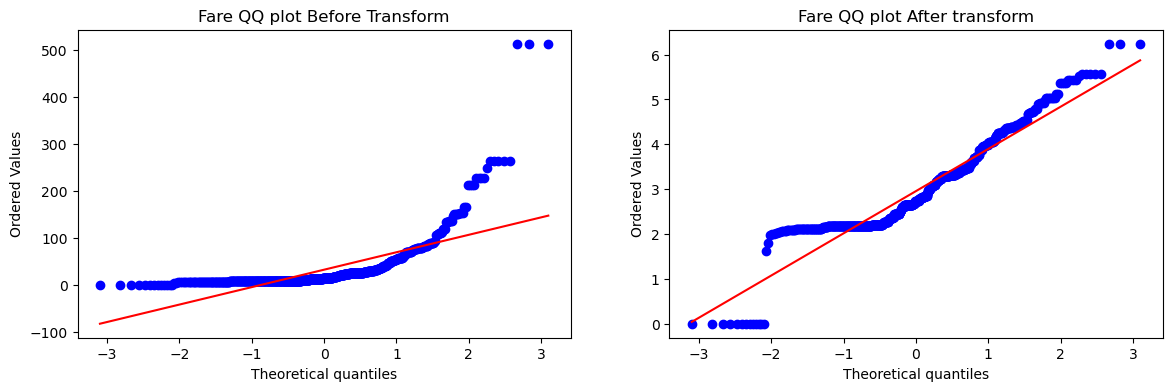

In [17]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ plot Before Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ plot After transform')

plt.show()

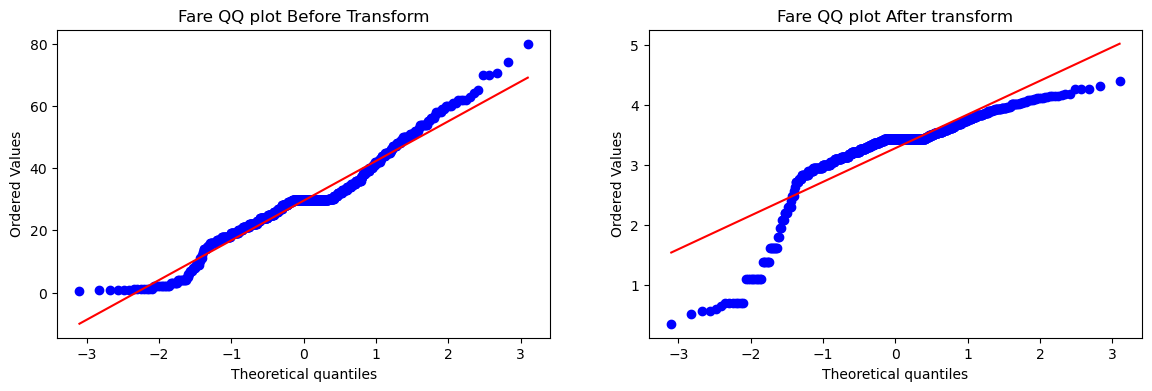

In [18]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Fare QQ plot Before Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Fare QQ plot After transform')

plt.show()

In [19]:
# here age is not well after trandformation
# LETS TRY transformation on fare only

In [20]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [21]:
lr = LogisticRegression()
clf = DecisionTreeClassifier()

In [22]:
lr.fit(X_train_transformed2, y_train)
clf.fit(X_train_transformed2, y_train)

y_pred_lr = lr.predict(X_test_transformed2)
y_pred_clf = clf.predict(X_test_transformed2)

print(f"LR Accuracy : {accuracy_score(y_pred_lr, y_test)}")
print(f"DT Accuracy : {accuracy_score(y_pred_clf, y_test)}")

LR Accuracy : 0.6703910614525139
DT Accuracy : 0.664804469273743


In [23]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf, X_transformed2,y, scoring='accuracy' , cv=10) ) )
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y, scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6622097378277153


In [24]:
df.sample()

,Survived,Age,Fare
588,0,22.0,8.05


In [31]:
def apply_transform(transform):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]
    
    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
    
    X_trans = trf.fit_transform(X)

    clf = DecisionTreeClassifier()

    print('Accuracy', np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot=plt)
    plt.title('Fare before transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist='norm', plot=plt)
    plt.title('Fare After transform')

    plt.show()

Accuracy 0.6565792759051187


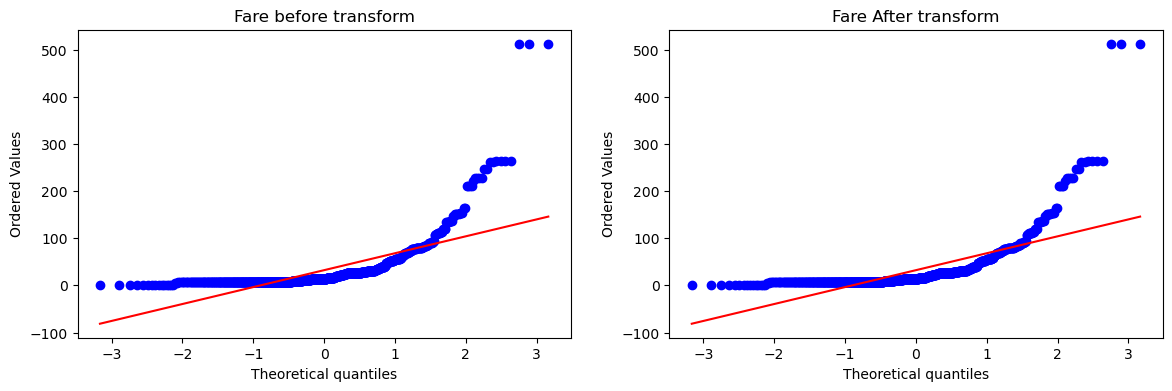

In [35]:
apply_transform(lambda x : x)

Accuracy 0.6599625468164794


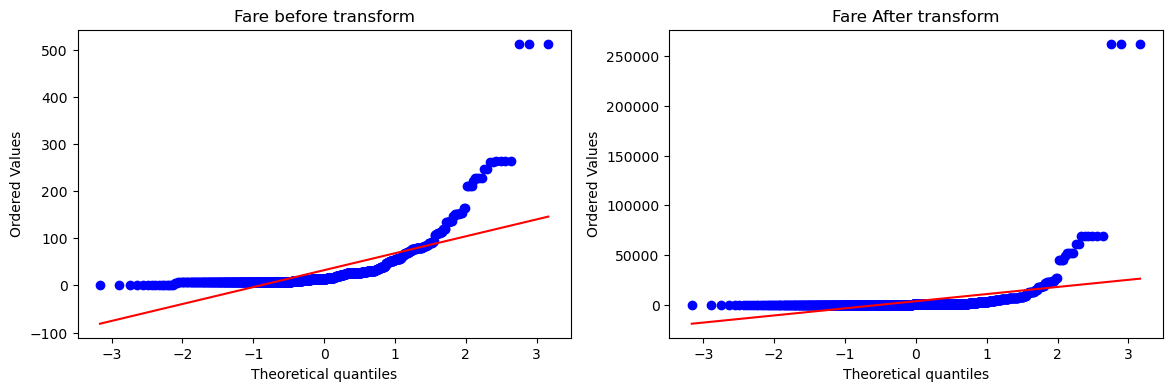

In [36]:
apply_transform(lambda x : x**2)

Accuracy 0.6599750312109862


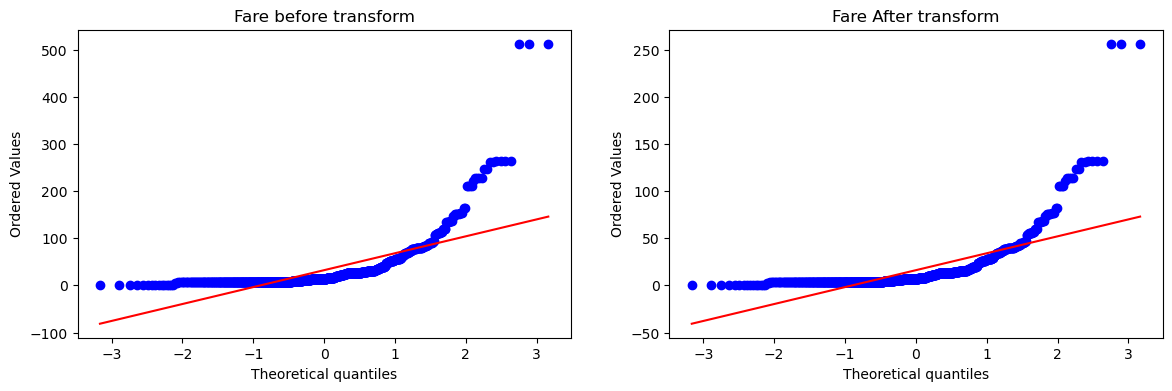

In [38]:
apply_transform(lambda x : x**1/2)